# Introduction

In this notebook, we are going to perform exploratory data analysis on our feature space. We are going to analyze them uniformly, their dynamics with weather heatwave days and non-heatwave days and, dynamics with different heatwave severity occurrences in case of heatwave days.

**! Note:** We decided to perform analyses and modelling in 2004-2024 time range at beginning of this whole project. But, during previous notebook `04_heatwave_analysis.ipynb`, we detected that, heatwaves distinguishes between before 2000 and after 2000 in terms of frequencies, durations, worse heatwave cases. The post 2000 time space represents our current circumstance of heatwave events in long term. Since we want to keep and make our analyses more robust / complete, also increase our dataset size, we've extended our time range to 2000-2024 (closed interval). We've done fetching and merging of missing first 4 years of data in an extra out of order notebook called `extra_additional_data_fetching.ipynb`. It is located in same directory with this notebook.

# Imports and Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

from src.general_utils import ks_test_by_heatwave
from src.plotting_utils import (
                                plot_time_slice, 
                                plot_with_time_range, 
                                plot_components,
                                plot_winddir_heatmap,
                                joint_plots_with_severity
                                )

from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
adelaide_df = pd.read_csv(
    "data/processed/adelaide_hourly_weather_cleaned.csv",
    parse_dates=["datetime_utc"],
    index_col="datetime_utc"
)
adelaide_df["datetime_local"] = adelaide_df.index.tz_convert("Australia/Adelaide")

Because of our heawave definition and indices in daily resolution, we are going to downsample all features to daily resolution. Both our analyses / surveys and predictive modelling are going to be in daily resolution.

In [3]:
mean_columns = ['relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'pressure_msl', 'wind_speed_10m', 'cloud_cover',
       'shortwave_radiation', 'wet_bulb_temperature_2m', 'month_local', 'wind_unit_x', 'wind_unit_y', 'DMT', 'tmin', 'tmax',
       'EHI_sig', 'EHI_accl', 'EHF', 'EHF_sev']

#! Change index 
adelaide_df['datetime_utc'] = adelaide_df.index
adelaide_df.set_index('datetime_local', inplace=True)

daily_df = adelaide_df[mean_columns].resample('D').mean()
daily_df['precipitation'] = adelaide_df['precipitation'].resample('D').sum()
daily_df['wind_direction_compass'] = adelaide_df['wind_direction_compass'].resample('D').first()
daily_df['severity'] = adelaide_df['severity'].resample('D').first()
daily_df['heat_wave'] = daily_df['EHF'] > 0 # Convenience column

# ! Re-Change index
adelaide_df["datetime_local"] = adelaide_df['datetime_utc'].tz_convert("Australia/Adelaide")
adelaide_df.set_index('datetime_utc', inplace=True)

daily_df.head()

,relative_humidity_2m,dew_point_2m,apparent_temperature,pressure_msl,wind_speed_10m,cloud_cover,shortwave_radiation,wet_bulb_temperature_2m,month_local,wind_unit_x,...,tmin,tmax,EHI_sig,EHI_accl,EHF,EHF_sev,precipitation,wind_direction_compass,severity,heat_wave
datetime_local,,,,,,,,,,,,,,,,,,,,,
2000-01-01 00:00:00+10:30,58.375954,6.854583,11.690625,1018.404172,22.481411,25.791667,338.208333,10.507936,1.0,-0.859000,...,12.29,19.740000,-8.062083,-1.385000,-8.062083,0.0,0.0,SE,No-heatwave,False
2000-01-02 00:00:00+10:30,53.894292,8.606667,17.562999,1014.966667,13.889992,17.791667,381.666667,13.051835,1.0,-0.590170,...,13.89,25.490000,-7.820417,-0.857500,-7.820417,0.0,0.0,SE,No-heatwave,False
2000-01-03 00:00:00+10:30,59.922957,10.537917,17.466684,1013.208338,17.923586,18.916667,377.500000,14.051188,1.0,-0.738965,...,12.79,25.189999,-8.895417,-2.030833,-8.895417,0.0,0.0,SE,No-heatwave,False
2000-01-04 00:00:00+10:30,51.373941,5.492083,11.487354,1020.416664,27.433249,17.791667,379.583333,10.278888,1.0,-0.985043,...,13.14,20.340000,-9.395417,-2.589167,-9.395417,0.0,0.0,S,No-heatwave,False
2000-01-05 00:00:00+10:30,54.446861,6.762917,12.839374,1022.775004,21.999236,32.166667,361.125000,10.918418,1.0,-0.904516,...,11.89,21.039999,-8.628750,-1.765000,-8.628750,0.0,0.0,S,No-heatwave,False


In [ ]:
# Saving daily frequency data for later use.
daily_df.to_csv("data/processed/adelaide_daily_weather_cleaned.csv", index=True, index_label="datetime_local")

In [6]:
# Loading cell for later use
daily_df = pd.read_csv("data/processed/adelaide_daily_weather_cleaned.csv", index_col="datetime_local")
daily_df.index = pd.to_datetime(daily_df.index, utc=True).tz_convert("Australia/Adelaide")
daily_df.head()

,relative_humidity_2m,dew_point_2m,apparent_temperature,pressure_msl,wind_speed_10m,cloud_cover,shortwave_radiation,wet_bulb_temperature_2m,month_local,wind_unit_x,...,tmin,tmax,EHI_sig,EHI_accl,EHF,EHF_sev,precipitation,wind_direction_compass,severity,heat_wave
datetime_local,,,,,,,,,,,,,,,,,,,,,
2000-01-01 00:00:00+10:30,58.375954,6.854583,11.690625,1018.404172,22.481411,25.791667,338.208333,10.507936,1.0,-0.859000,...,12.29,19.740000,-8.062083,-1.385000,-8.062083,0.0,0.0,SE,No-heatwave,False
2000-01-02 00:00:00+10:30,53.894292,8.606667,17.562999,1014.966667,13.889992,17.791667,381.666667,13.051835,1.0,-0.590170,...,13.89,25.490000,-7.820417,-0.857500,-7.820417,0.0,0.0,SE,No-heatwave,False
2000-01-03 00:00:00+10:30,59.922957,10.537917,17.466684,1013.208338,17.923586,18.916667,377.500000,14.051188,1.0,-0.738965,...,12.79,25.189999,-8.895417,-2.030833,-8.895417,0.0,0.0,SE,No-heatwave,False
2000-01-04 00:00:00+10:30,51.373941,5.492083,11.487354,1020.416664,27.433249,17.791667,379.583333,10.278888,1.0,-0.985043,...,13.14,20.340000,-9.395417,-2.589167,-9.395417,0.0,0.0,S,No-heatwave,False
2000-01-05 00:00:00+10:30,54.446861,6.762917,12.839374,1022.775004,21.999236,32.166667,361.125000,10.918418,1.0,-0.904516,...,11.89,21.039999,-8.628750,-1.765000,-8.628750,0.0,0.0,S,No-heatwave,False


In [8]:
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9132 entries, 2000-01-01 00:00:00+10:30 to 2024-12-31 00:00:00+10:30
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   relative_humidity_2m     9132 non-null   float64
 1   dew_point_2m             9132 non-null   float64
 2   apparent_temperature     9132 non-null   float64
 3   pressure_msl             9132 non-null   float64
 4   wind_speed_10m           9132 non-null   float64
 5   cloud_cover              9132 non-null   float64
 6   shortwave_radiation      9132 non-null   float64
 7   wet_bulb_temperature_2m  9132 non-null   float64
 8   month_local              9132 non-null   float64
 9   wind_unit_x              9132 non-null   float64
 10  wind_unit_y              9132 non-null   float64
 11  DMT                      9132 non-null   float64
 12  tmin                     9132 non-null   float64
 13  tmax                     9132 

# Univariate Analysis

We've done heatwave focused univariate analysis in the previous notebook, `04_heatwave_analysis.ipynb`. In this section, we are going to do univariate analysis for *some* of directly temperature / heatwave related features. This part is no going to be very detailed, due to our main motivation is studying relations and dynamics between features, heatwaves and heatwave severity classes, aka. *bivariate analysis*.

In [ ]:
plot_with_time_range(df=daily_df, col_names=['relative_humidity_2m', 'dew_point_2m', 'apparent_temperature','pressure_msl', 'wind_speed_10m', 
                                            'cloud_cover', 'shortwave_radiation', 'wet_bulb_temperature_2m','DMT', 'EHF'], x_axis='index')

![image](plot_img/05_columns.png)

**!** Cell output is replaced with its image due to its size. To display and check original plot, one should run all previous cells before this cell.

We can examine numerical variables over time on above plot. Most of are have yearly seasonal patterns. We are going to decompose several of them for sake of demonstration and initial exploration. 

**! Caution,** they will be downsampled to *monthly frequency* to be able to see yearly seasonality better.

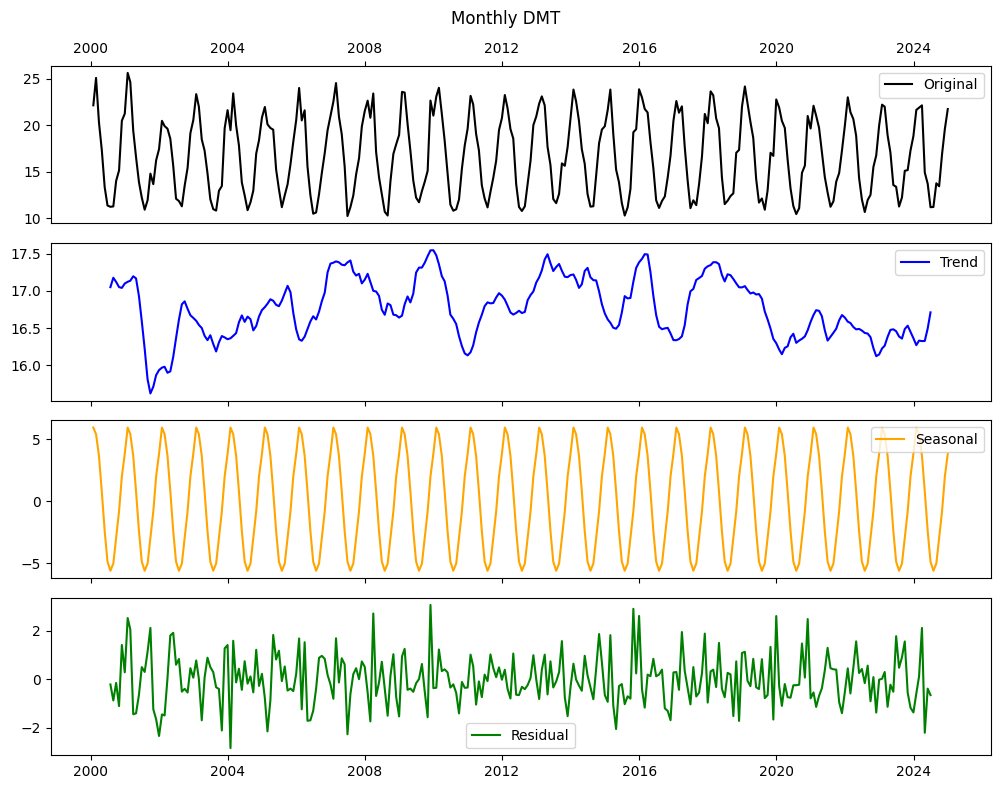

In [5]:
monthly_dmt = daily_df['DMT'].resample('ME').mean()
monthly_dmt_comp = seasonal_decompose(monthly_dmt, period=12, model='additive')
plot_components('Monthly DMT', monthly_dmt_comp)

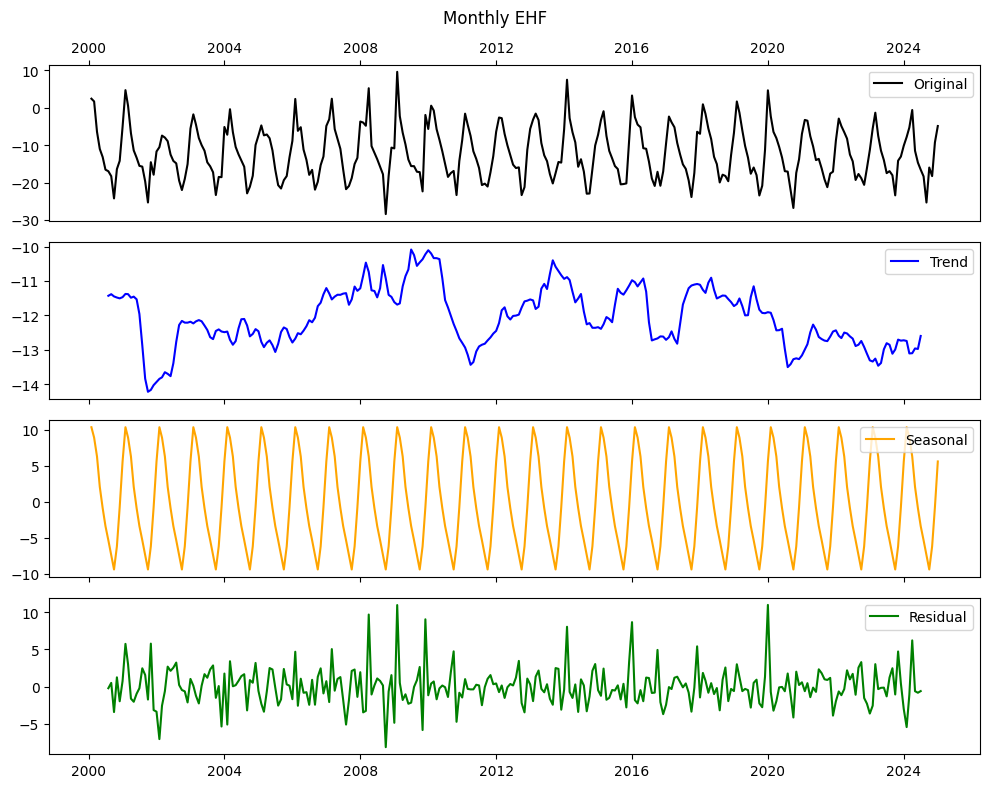

In [6]:
monthly_ehf = daily_df['EHF'].resample('ME').mean()
monthly_ehf_comp = seasonal_decompose(monthly_ehf, period=12, model='additive')
plot_components('Monthly EHF', monthly_ehf_comp)

When we look 2009 and 2020 residuals of EHF, we can see the outliers. They are related to the known extreme heatwaves.

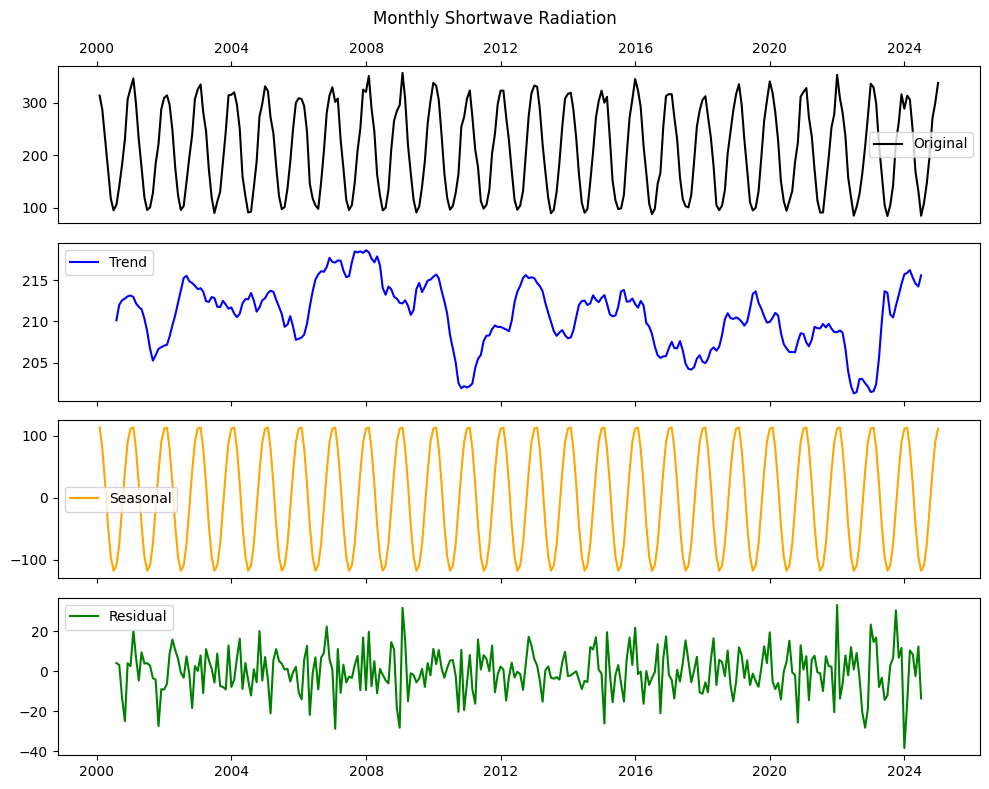

In [7]:
monthly_radiation = daily_df['shortwave_radiation'].resample('ME').mean()
monthly_radiation_comp = seasonal_decompose(monthly_radiation, period=12, model='additive')
plot_components('Monthly Shortwave Radiation', monthly_radiation_comp)

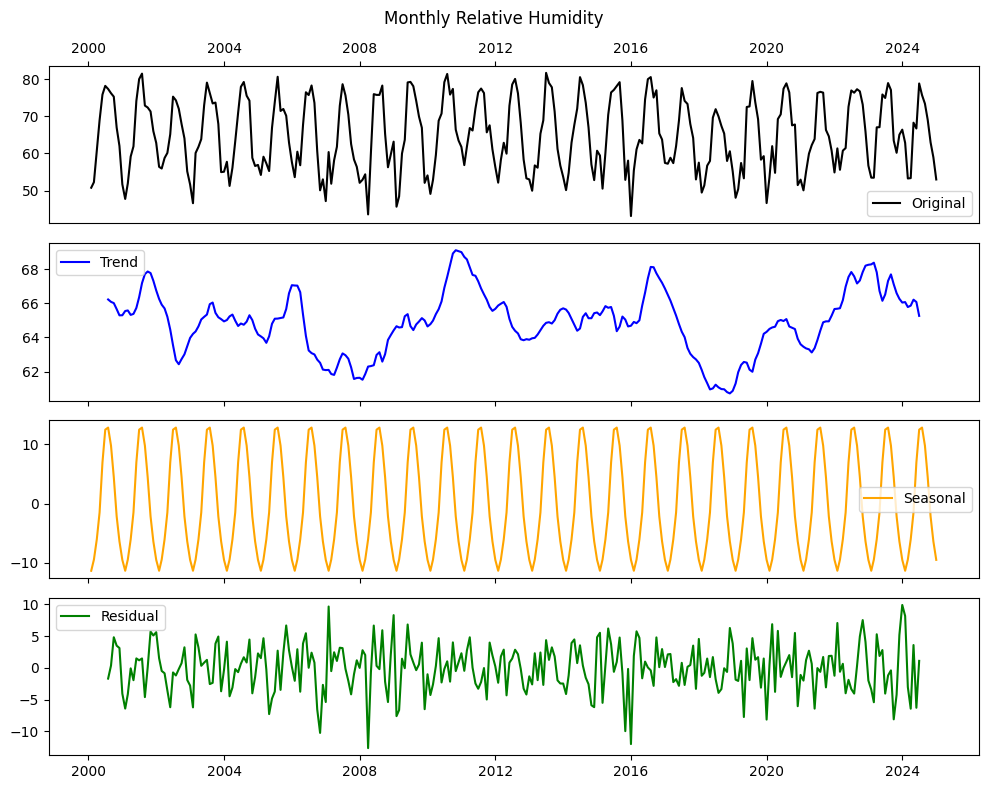

In [8]:
monthly_rh = daily_df['relative_humidity_2m'].resample('ME').mean()
monthly_rh_comp = seasonal_decompose(monthly_rh, period=12, model='additive')
plot_components('Monthly Relative Humidity', monthly_rh_comp)

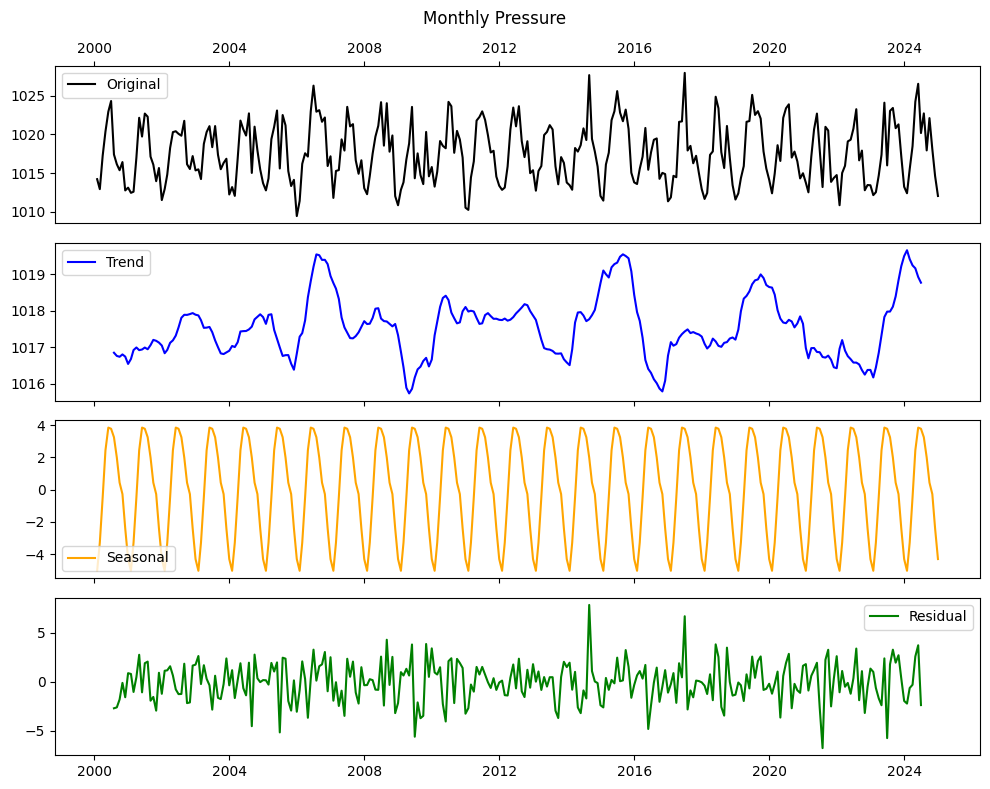

In [9]:
monthly_press = daily_df['pressure_msl'].resample('ME').mean()
monthly_press_comp = seasonal_decompose(monthly_press, period=12, model='additive')
plot_components('Monthly Pressure', monthly_press_comp)

Each of these variables' evolution in time make sense on their own. Seasonalities make sense, e.g. `shortwave_radiation`'s peak in summer and `relative_humidity_2m`'s peak in winter. 

Trends seem not stable across years but it is just an visual illusion due to plots range. We could have increase overall range of them and show it as stable. We did not do it to display that correlated variables trends behave and evolves reasonably according to physical and natural laws. For example, we can see `DMT`'s possitive correlation with `shortwave_radiation`, negative correlation with `relative_humidity_2m` on trend plots, as well as we can see on seasonalities. We'll now show correlations of decomposed variables above by plotting trends and seasonal components at beginning of bivariate analysis, which is the next section. 

Before that, let's get rid of this unstable trend confusion by plottting them more conveniently. 

In [13]:
# Gathering trends in a dataframe
monthly_trends = pd.DataFrame({'DMT': monthly_dmt_comp.trend, 'EHF': monthly_ehf_comp.trend, 'shotwave_radiation': monthly_radiation_comp.trend,
                           'relative_humidity_2m': monthly_rh_comp.trend, 'pressure_msl': monthly_press_comp.trend})
monthly_trends.index = monthly_dmt.index

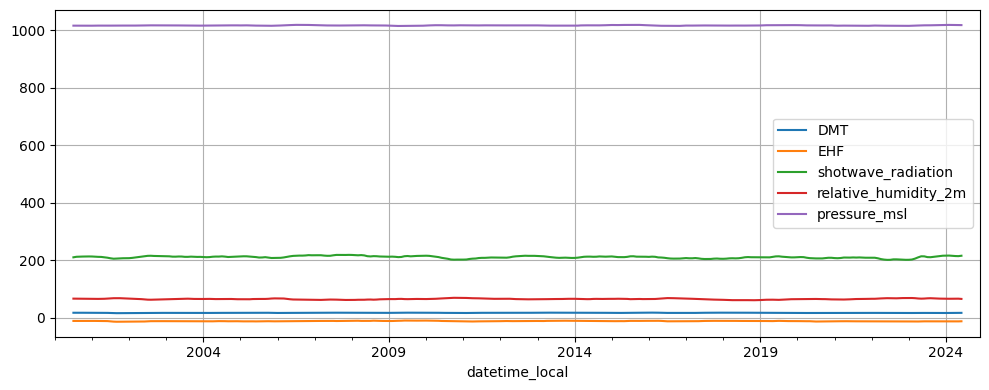

In [14]:
plot_time_slice(monthly_trends, monthly_trends.index.min(), monthly_trends.index.max(), 
                ['DMT', 'EHF', 'shotwave_radiation', 'relative_humidity_2m', 'pressure_msl'], subplots=False)

As we can see they are almost a straight line in time. Now back to analysis.

# Bivariate Analysis

This section is going to our main focus in this notebook. Because our motivation is how other air condition features behave when whether there is a heatwave or not. And how they behave under different heatwave severity classes. 

## Trend and Seasonal Component Plots
We are going to inspect decomposed variables' trends and seasonal components above by plotting them.

In [16]:
# Gathering seasonal components in a dataframe as well
monthly_seasonal = pd.DataFrame({'DMT': monthly_dmt_comp.seasonal, 'EHF': monthly_ehf_comp.seasonal, 'shotwave_radiation': monthly_radiation_comp.seasonal,
                           'relative_humidity_2m': monthly_rh_comp.seasonal, 'pressure_msl': monthly_press_comp.seasonal})
monthly_seasonal.index = monthly_dmt.index 

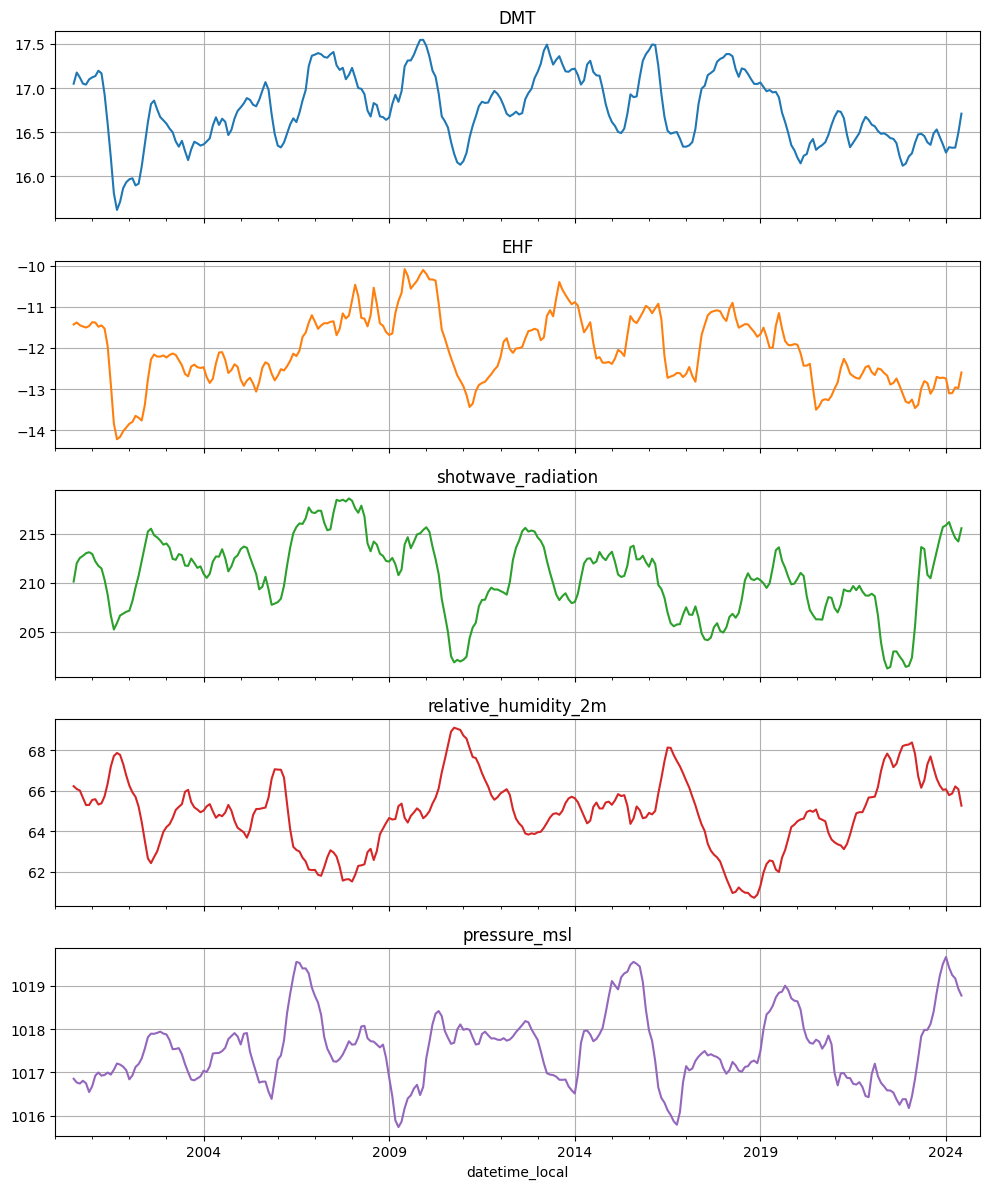

In [20]:
plot_time_slice(monthly_trends, monthly_trends.index.min(), monthly_trends.index.max(), 
                ['DMT', 'EHF', 'shotwave_radiation', 'relative_humidity_2m', 'pressure_msl'], subplots=True)

Explanations are after next seasonal plots cell.

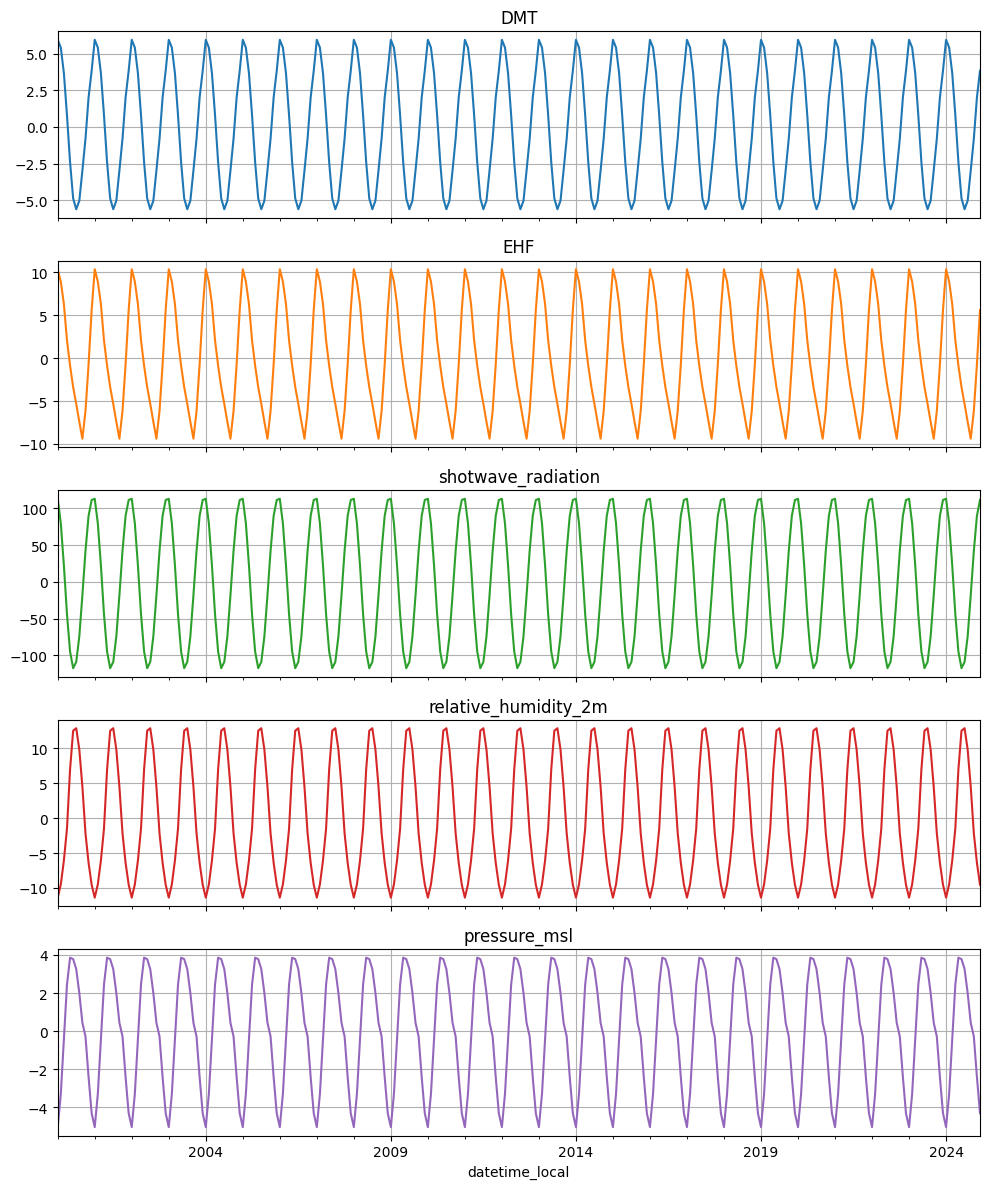

In [21]:
plot_time_slice(monthly_seasonal, monthly_seasonal.index.min(), monthly_seasonal.index.max(), 
                ['DMT', 'EHF', 'shotwave_radiation', 'relative_humidity_2m', 'pressure_msl'], subplots=True)

When we look at these two groups of plots, positive correlation of `DMT, EHF, shortwave_radiaton` among each other can be seen. On top of that, we can see that `relative_humidity_2m` and `pressure_msl` columns are negatively correlated with first 3 tmeperature related columns. 

This was an initial check of correlations by visual inspection of seasonal and trend plots. In the next section, we are going to check correlations of all numerical columns.

## Numerical Column Correlations

In [7]:
numeric_columns = daily_df.select_dtypes(include=['number']).columns
numeric_columns

Index(['relative_humidity_2m', 'dew_point_2m', 'apparent_temperature',
       'pressure_msl', 'wind_speed_10m', 'cloud_cover', 'shortwave_radiation',
       'wet_bulb_temperature_2m', 'month_local', 'wind_unit_x', 'wind_unit_y',
       'DMT', 'tmin', 'tmax', 'EHI_sig', 'EHI_accl', 'EHF', 'EHF_sev',
       'precipitation'],
      dtype='object')

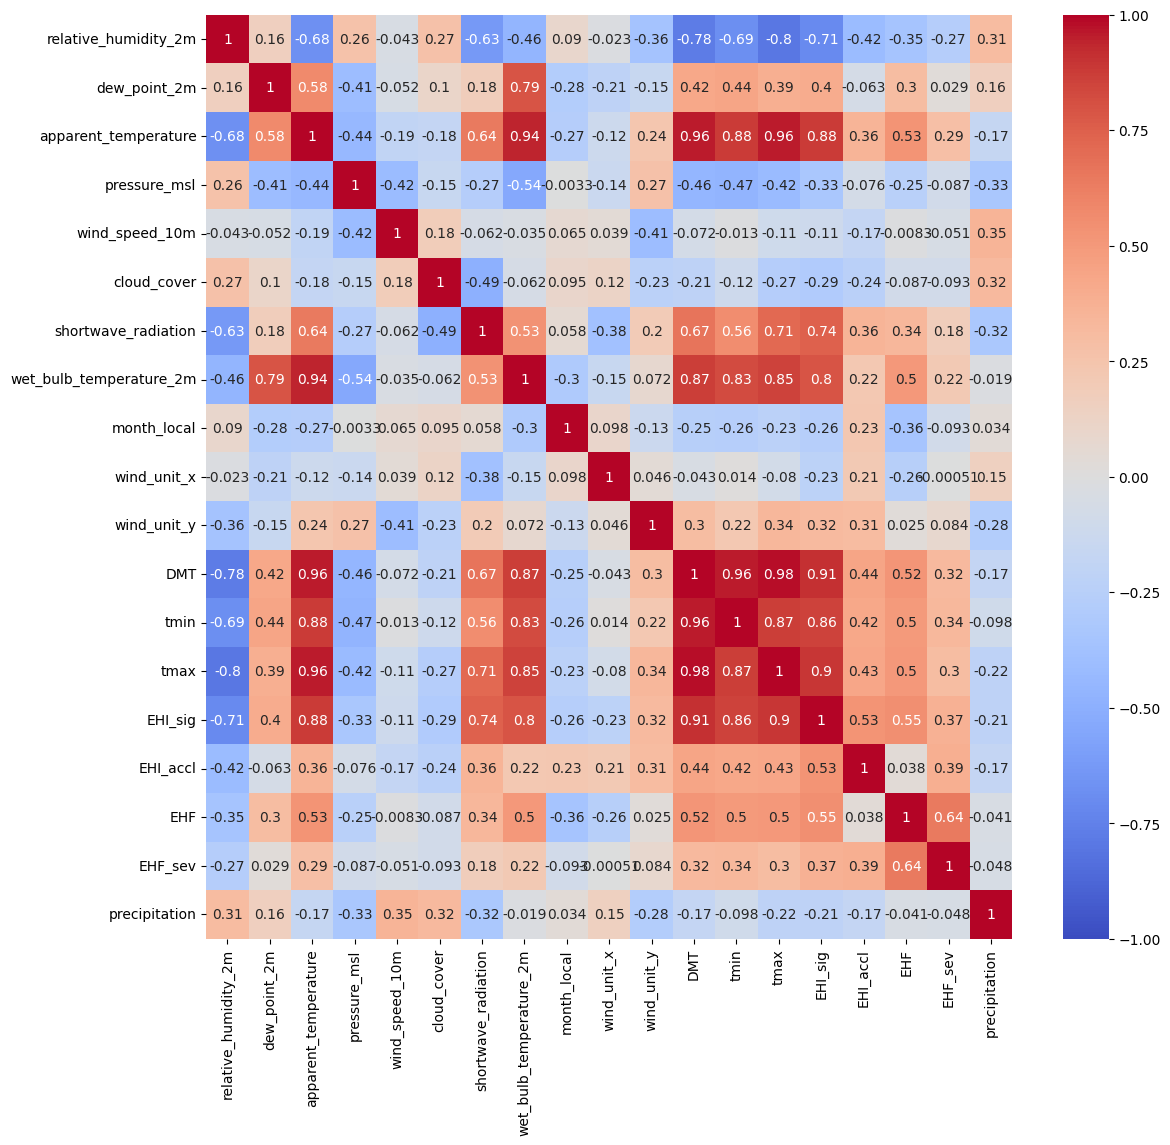

In [8]:
size = int(len(numeric_columns) * (2/3))
plt.figure(figsize=(size+1, size))
sns.heatmap(daily_df[numeric_columns].corr(), annot=True, vmin=-1, vmax=1, cmap='coolwarm')
plt.show()              

**Directly Temperature Related Variables (DTRV):** `DMT`, `tmin`, `tmax`, `EHF`, `EHI_sig`, `EHI_accl`, `EHF_sev`, `apparent_temperature`, `shortwave_radiation`, `wet_bulb_temperature_2m`, `dew_point_2m`

As we can see, DTRV columns has high positive correlations each other. But with some exceptions:

* `EHI_accl` and implicitly `EHF` have lower correlations with others. Reason is, last 30 days `DMT` values are used at derivation of `EHI_accl`, eventually high range of input values cause higher variety at `EHI_accl` values. 

* `dew_point_2m` has lower correlations with other DTRV columns, due to this variable affected by humidity. It is actually by its definition. Even we can't see any correlation between `dew_point_2m` and `relative_humidity_2m`, we can see they are aligned at some degree in time. We plotted a 2 months slice of them below. 

* `relative_humidity_2m` column has decent negative correlation with DRTV columns, as naturally it should be.

* `pressure_msl` has some negative correlation with DTRV: As temperature increases, air disperses and become less dense in open space. Less dense air means less pressure. Spesifically noting this one, due to there is a potential of it might be confused with *"closed space temperature / pressure dynamics"*. Which has reverse relation with our case. 

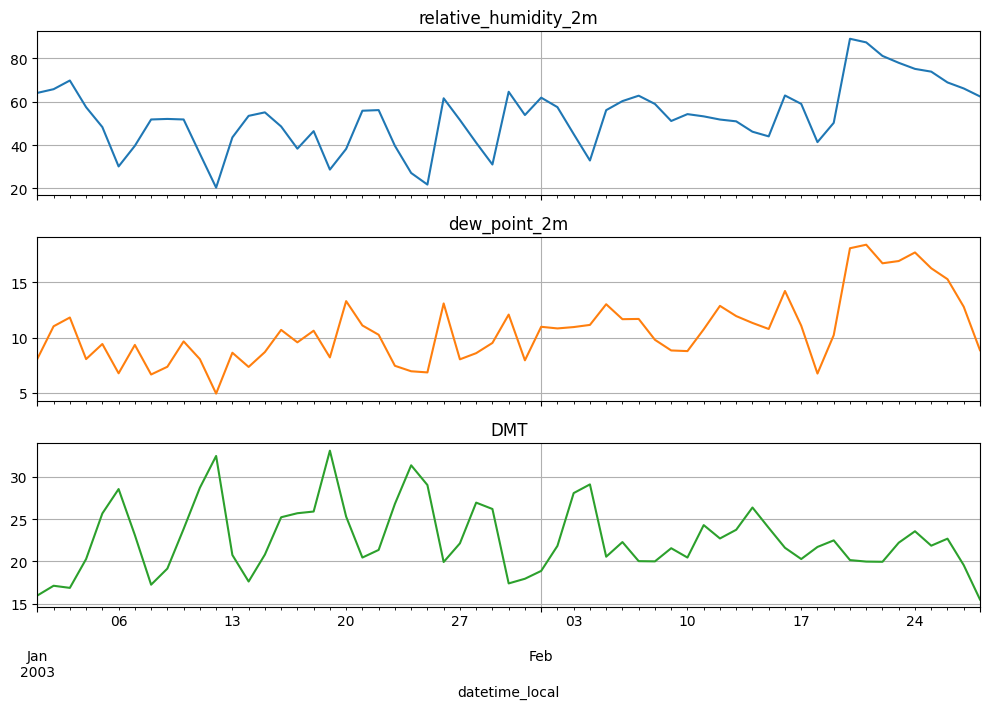

In [22]:
plot_time_slice(daily_df, start_date='2003-01-01', end_date='2003-02-28', columns=['relative_humidity_2m', 'dew_point_2m','DMT'])

**!** There is a fact to be noticed, is `wind_unit_y` has low positive correlation with DTRV and negative correlation with `relative_humidity_2m` and `wind_speed_10m`. Actually lets see these variables on a joint kde plot. (Not going to plot all DTRV, only the ones has correlation with `wind_unit_y`.)

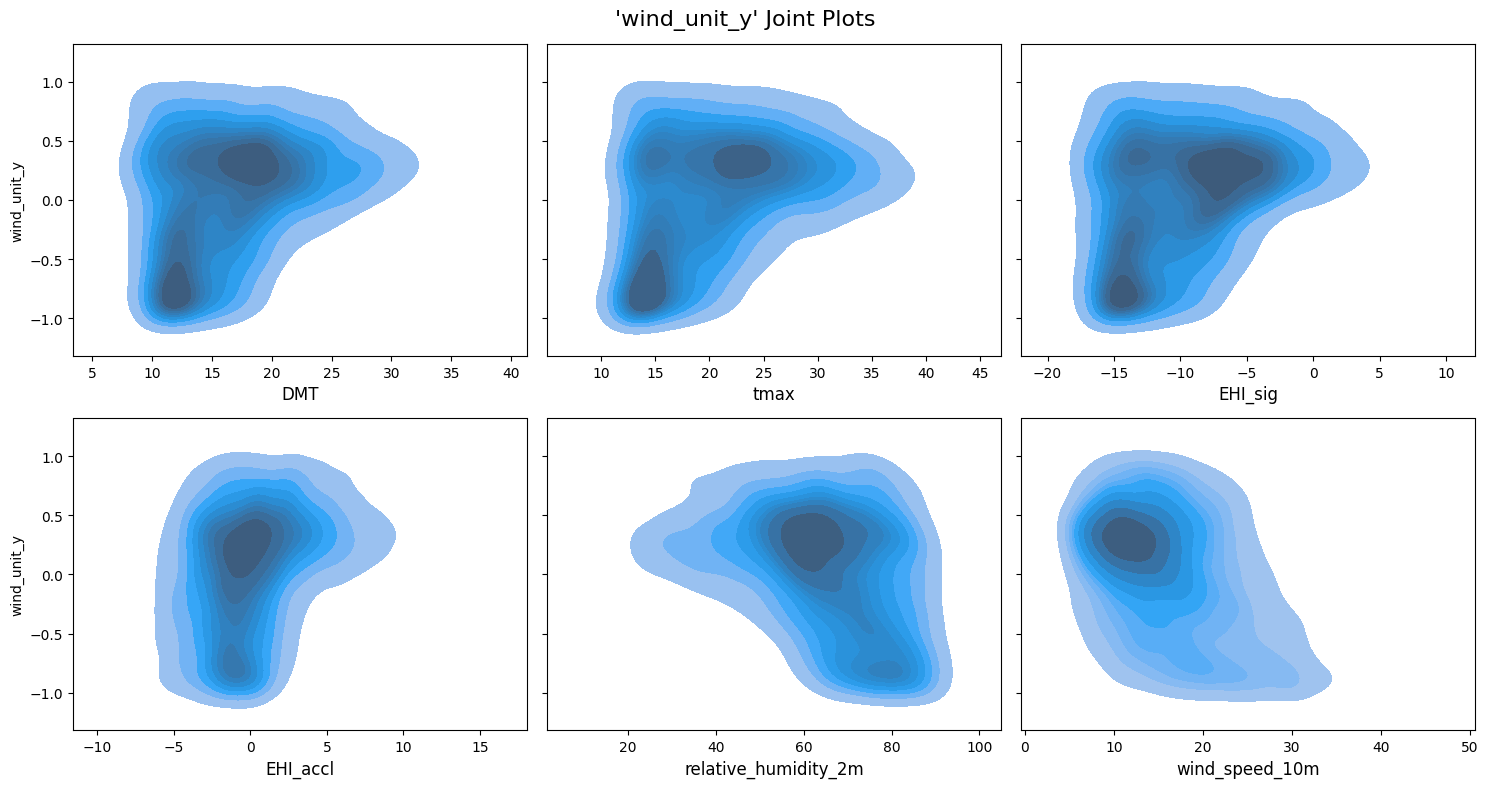

In [24]:
x_cols = ['DMT', 'tmax', 'EHI_sig', 'EHI_accl', 'relative_humidity_2m', 'wind_speed_10m']
fig, ax = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
plt.suptitle("'wind_unit_y' Joint Plots", fontsize=16)
for i, c in enumerate(x_cols):
    sns.kdeplot(data=daily_df, x=c, y='wind_unit_y', fill=True, ax=ax[i//3][i%3])
    ax[i//3][i%3].set_xlabel(c, fontsize=12)

fig.tight_layout()
plt.show()

When we look to first row plots we can see there are two parts instances get dense. If we explain it by `DMT`: First, *[10, 15]* `DMT` interval matches with *[-0.5, -1]* `wind_unit_y` interval. Second, *[15, 20]* `DMT` interval matches with *[0, 0.5]* `wind_unit_y` interval. According to these two dense parts, south half winds are correlated with lower temperature values while north half winds are correlated with higher temperature values. But in general and majority of instances, not as a necessary, strict interpretation. Also `relative_humidity_2m`'s low negative correlation with `wind_unit_y` can be seen too. At some degree, these facts might be associated with that Australia is at southern hemisphere.

There is another fact to be noticed: Northern dense part gathered at *[0, 0.5]* `wind_unit_y` while southern dense part gathered at *[-0.5, -1]* `wind_unit_y`. Means, subject northern winds are either from around *Northwest* or *Northeast* directions while subject southern winds are from around *South* direction.

We are going to examine wind directions in the next section, especially relationships with heatwave events.

## Wind Direction Analysis

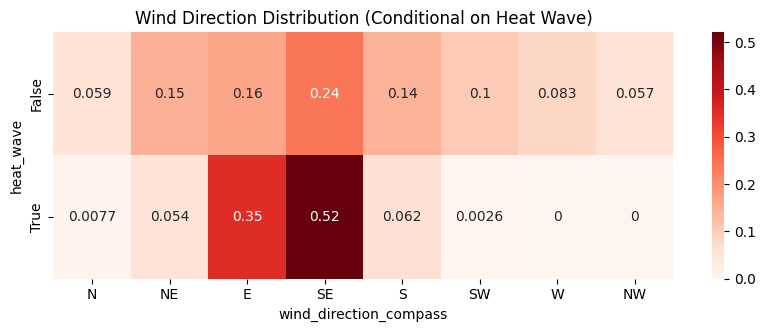

In [44]:
cross_tab_winddir_heatwave = pd.crosstab(daily_df['wind_direction_compass'], daily_df['heat_wave'])
plot_winddir_heatmap(cross_tab_winddir_heatwave, 'Wind Direction Distribution (Conditional on Heat Wave)', 
                     conditional=True, condition_on='x')

As we can see, when there is heatwave, wind direction is mostly **East** and **South-East**. Two direction's total portion is 87% among heatwave days. However, when there is no heat wave, wind direction is mostly distributed between **North-East, East, South-East and  South**. 

Also, when there is heatwave, wind direction is never **West** or **North-West**.

**!! BUT !!:** This should not misguide us, because we have conditioned on whether there is heatwave or not. If we approach things from predictive modelling perspective and condition on wind direction which is the actual dependent variable,  

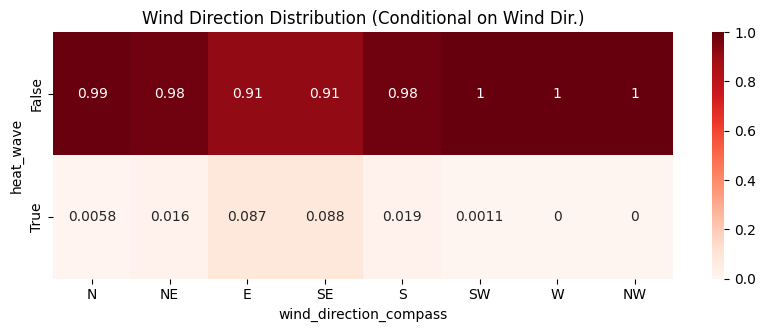

In [45]:
plot_winddir_heatmap(cross_tab_winddir_heatwave, 'Wind Direction Distribution (Conditional on Wind Dir.)', 
                     conditional=True, condition_on='y')

As we can see only wind direction is not a good predictor, even 91% of *East* and *South-East* wind direction days are not heatwave days.

**!** Although, we could still use this a predictor variable, even its importance will most likely be low. But, that is only when we look from perspective of direct relation of wind direction and heatwaves. The thing is, we couldn't know how much it would have seperation / predictive power when we count on dynamics with other variables too.

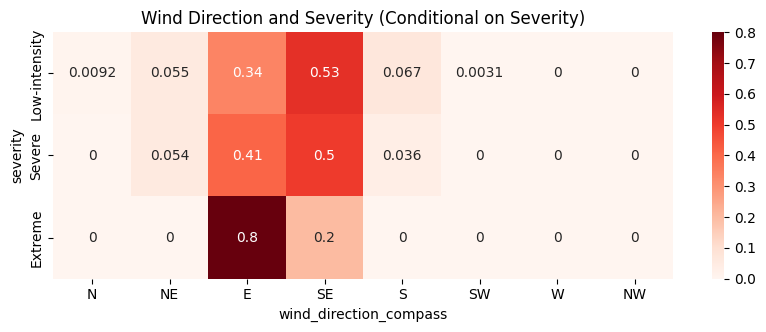

In [46]:
heat_wind = daily_df.loc[daily_df['heat_wave']==True, ['wind_direction_compass', 'severity']]
wind_dir_severity = pd.crosstab(heat_wind['wind_direction_compass'], heat_wind['severity'])
wind_dir_severity = wind_dir_severity[['Low-intensity', 'Severe', 'Extreme']]
plot_winddir_heatmap(wind_dir_severity, 'Wind Direction and Severity (Conditional on Severity)', conditional=True)

In [47]:
print('Total number of Extreme Heat Waves:', daily_df.loc[daily_df['severity']=='Extreme'].shape[0])

Total number of Extreme Heat Waves: 5


**! Note:** This cross table is generated with only heatwave day instances and conditioned on severity.

For this conditional distribution, there is not much difference between wind direction and severity. We can see the consequence of wind directions gather mostly at **East** and **South-East** on severity distributions too. **!** Extreme class distribution should not misguide us, due to it has only 5 instances. Calling that *"When an extreme heatwave occurs, wind direction 80% is east."* would be brave.

## 'severity' Column Analysis

In this section, numerical variables are examined both for their ability to distinguish heatwave days from non-heatwave days, and for how their distribution changes across heatwave severity levels.

In [15]:
cols = ['DMT', 'relative_humidity_2m', 'dew_point_2m', 'precipitation', 
        'pressure_msl', 'wind_speed_10m', 'cloud_cover',
        'shortwave_radiation', 'wet_bulb_temperature_2m']
colors = {"No-heatwave": "#19d829e4", "Low-intensity": "#fcec00", "Severe": "#fc8700", "Extreme": "#d41608"}

**!! NOTE:** We did not incluede `apparent_temperature_2m` column because it has almost same severity distributions with `DMT`, hence, to gain from space in plots. It can be verified by 0.96 correlation between them. (Look at the heat map in `Numerical Column Correlations` section up above.)

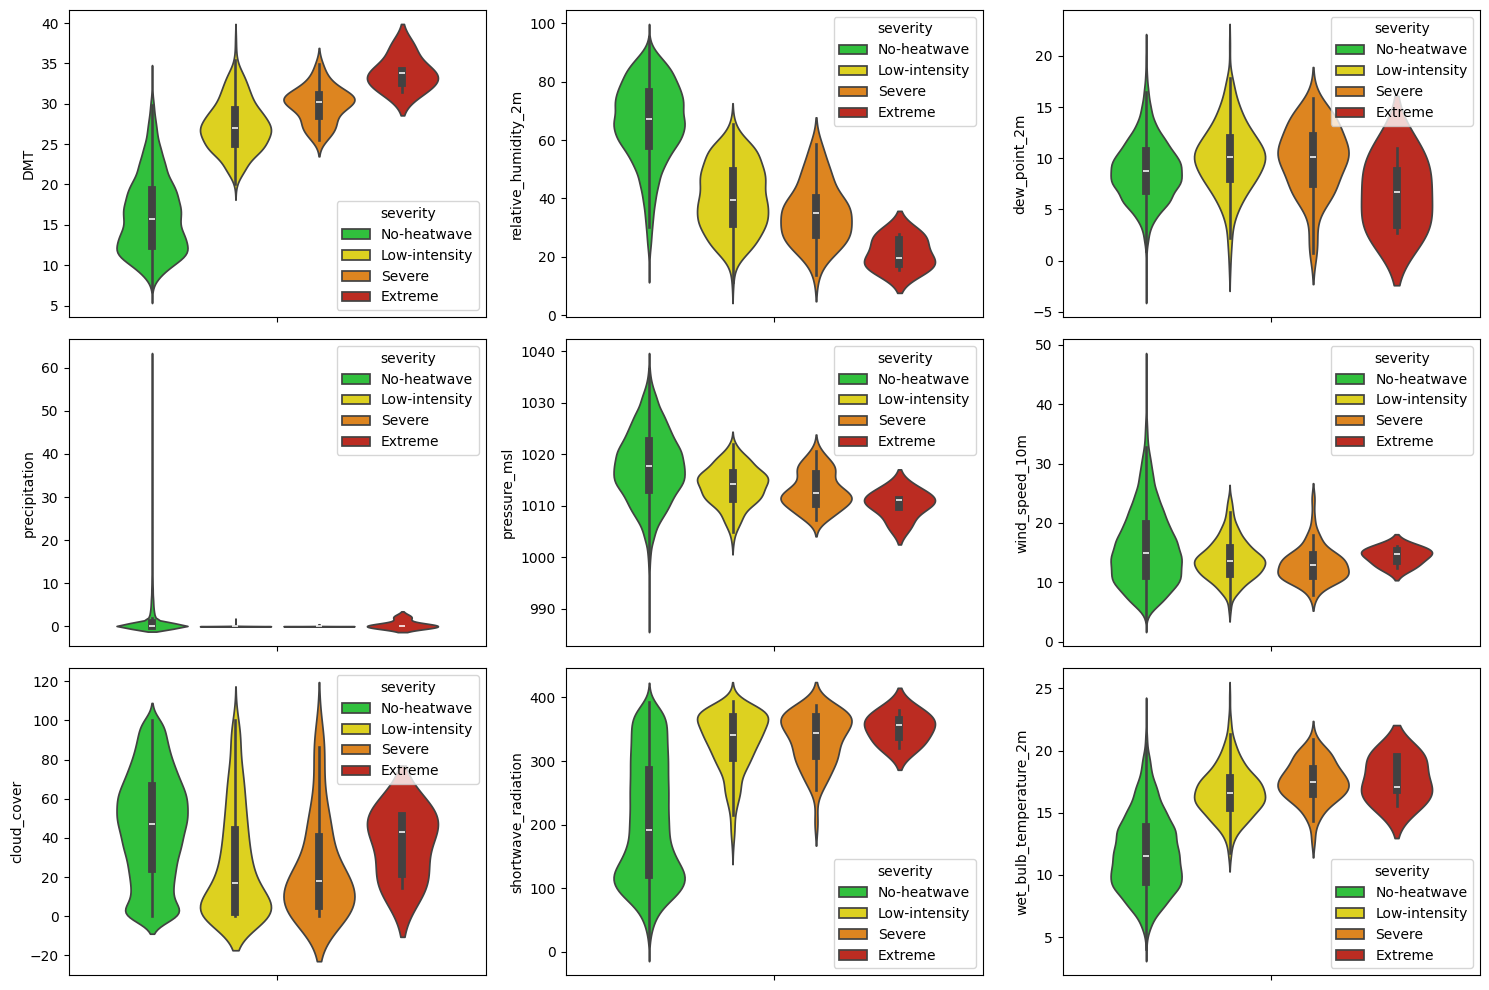

In [16]:
fig, ax = plt.subplots((len(cols)/3).__ceil__(), 3, figsize=(15, 10))

for i, c in enumerate(cols):
    sns.violinplot(data=daily_df, y=c, hue='severity', ax=ax[i//3][i%3], palette=colors, gap=0.15, legend='brief')

fig.tight_layout()
plt.show()

**Analyses:**

* **DMT** is the main originated variable of *Excess Heat Factor (EHF)*, thus seperation of heatwave days and not-heatwave days are obvious.
    - As severity increases, *DMT* ranges gather at higher values.
* **relative_humidity_2m**'s distinction in negative direction for heatwave days, due to physical/natural laws and the fact that temperature and humidity have a decent negative correlation as we've seen during **Numerical Column Correlations** section.
    - *Low-intensity* and *Severe* heatwaves' seperability are not so obvious, although *Extreme* class differs from other two with lower *relative_humidity_2m* values.

* **dew_point_2m** has no differentiability at all for neither heatwave days nor severity of heatwave events. This does **not** an **indicator** for heatwave events by only itself.

* **precipitation**'s existence is a negative indicator for heatwave events almost everytime. It has been seen before only during very rare *Extreme* events. But it does not mean vice versa, which means there might be not precipitation and heatwave at the same time.

* **pressure_msl**: During heatwave events, values are distributed in a shorter range than not-heatwave days', which is *1000-1025 hPa*. Although, not-heatwave days' most values are in this range too. This information might be still usefull to predict heatwave days.
    - Also, when we look at heatwave severity distributions, there is a slight decrease in *pressure_msl* values while severity increases.

* **wind_speed_10m**: Same situation as *pressure_msl*. Heatwave days values' are distributed in a shorter range, *3-25 m/s*. 

* **cloud_cover**: Heatwave days' values gathered at lower values than not-heatwave days' values. Although this is due to physical/natural laws, (cloud cover is higher in winter lower in summer), this information seems to be still usefull to predict heatwave days. 

* **shortwave_radiation**: Heatwave days' values gathered at higher values than not-heatwave days' values distinctively. This is most likely due to summer season (normal physical/natural laws). This information might be usefull to predict heatwave days.

* **wet_bulb_temperature_2m**: This variable's distributions almost matches with DMT, due to both of them are derived from temperature values. However, this variables values do not distinguish among heatwave severity classes as much as DMT values do.

**VERY IMPORTANT!:** Violin plots only show distribution ratios of each severity class in themselves. We've just inferred at the top that, some of variables are actually good candidates for predicting heatwave events. Matter of fact is heatwaves are rare, extreme events. So it is most likely that, *No-heatwave* category instances covers up the other three heatwave category instances, even at intervals *No-heatwave* category has low probability but other three heatwave categories has high probability. For example ``DMT`` > 20 interval: While 25% of all *No-heatwave* instances in this interval, almost all of heatwave days' instances in this interval. 

We are going to address this matter by other type of plots in the following sections. 

Before we go to the next section, let's take a look at the summer half of the year. Because as a result of physical/natural laws, heatwaves are more likely to occur in the summer, so, we are going to focus on how variables' severity distributions to check if they are different than the whole year. 

In [6]:
daily_df_summer = daily_df.loc[daily_df['month_local'].isin([10, 11, 12, 1, 2, 3])]
# Only October, November, December, January, February, March.

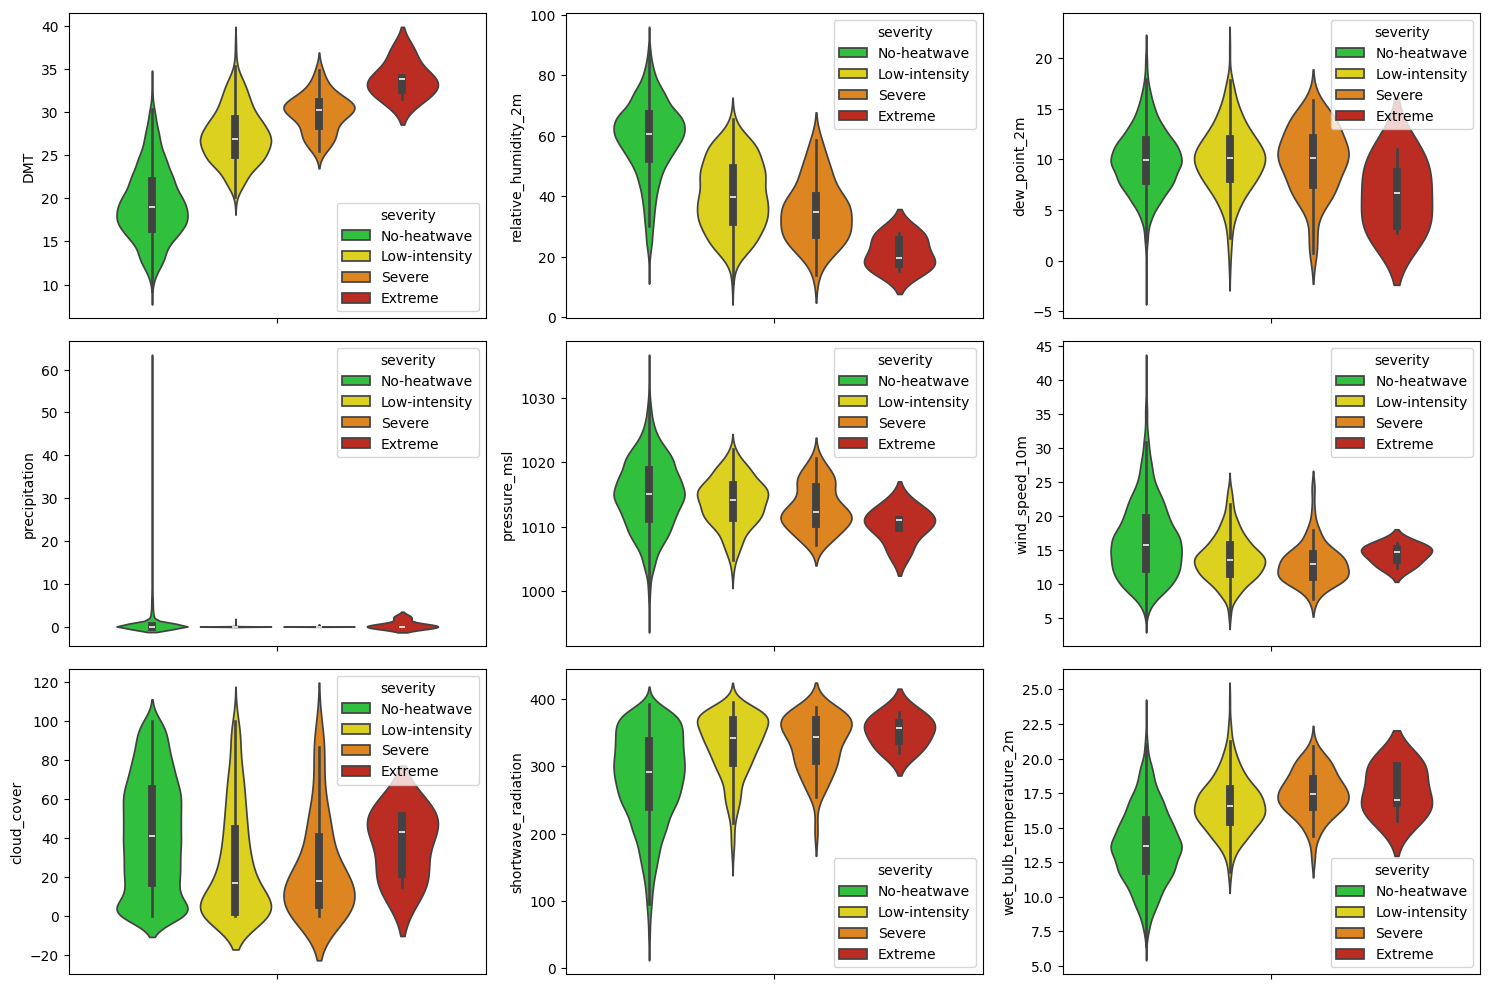

In [75]:
# Only summer half of the year
fig, ax = plt.subplots((len(cols)/3).__ceil__(), 3, figsize=(15, 10))
for i, c in enumerate(cols):
    sns.violinplot(data=daily_df_summer, y=c, hue='severity', ax=ax[i//3][i%3], palette=colors, gap=0.15, legend='brief')

fig.tight_layout()
plt.show()

**!!** We are focusing on only summer half of the years here to see if our analysis are consistent with the logic of heatwaves occur only this duration of year. As we can see, variables' distributions less distinctive than *all* year's distributions. Although they still keep the general trends. Somes are still differentiable, like *DMT, relative_humidity_2m, precipitation, wind_speed_10m* and *wet_bulb_temperature_2m*. We are going to check if these columns' heatwave days' and not-heatwave days' distributions are differentiable. We are going to use **Kolmogorov-Smirnov test** to check it statistically and support our findings quantatively.

If we would give a basic idea about the test: This test's null hypothesis is that the two samples are drawn from the same distribution and the alternative hypothesis is that the two samples are drawn from different distributions. We apply test between heatwave days and not-heatwave days for each variable.

In [11]:
from scipy.stats import ks_2samp

def ks_test_by_heatwave(
    df,
    column,
    heatwave_col='heat_wave',
    alpha=0.05,
    verbose=True
):
    """
    Apply two-sample Kolmogorov–Smirnov test between
    heatwave and no-heatwave days for a given column.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    column : str
        Numerical column to test.
    heatwave_col : str, default 'heat_wave'
        Binary column indicating heatwave days (True/False).
    alpha : float, default 0.05
        Significance level.
    verbose : bool, default True
        Whether to print interpretation.

    Returns
    -------
    dict with keys:
        'ks_statistic', 'p_value', 'n_heatwave', 'n_no_heatwave'
    """

    # Split samples
    hw = df.loc[df[heatwave_col] == True, column].dropna()
    nhw = df.loc[df[heatwave_col] == False, column].dropna()

    ks_stat, p_value = ks_2samp(hw, nhw)

    if verbose:
        print(f"KS Statistic: {ks_stat:.4f}")
        print(f"P-value: {p_value:.4e}")
        if p_value < alpha:
            print("Reject H0: Distributions differ.")
        else:
            print("Fail to reject H0: No strong evidence distributions differ.")

    return {
        "column": column,
        "ks_statistic": ks_stat,
        "p_value": p_value,
        "n_heatwave": len(hw),
        "n_no_heatwave": len(nhw)
    }

In [12]:
results = []
for c in ['DMT', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'wet_bulb_temperature_2m']:
    results.append(ks_test_by_heatwave(daily_df_summer, c, verbose=False))

pd.DataFrame(results).round(4)

,column,ks_statistic,p_value,n_heatwave,n_no_heatwave
0,DMT,0.7509,0.0,387,4170
1,relative_humidity_2m,0.5954,0.0,387,4170
2,precipitation,0.2619,0.0,387,4170
3,wind_speed_10m,0.2770,0.0,387,4170
4,wet_bulb_temperature_2m,0.5195,0.0,387,4170


As we can see by looking at *p-values* (all rounded down to 0), emprical distributions of heatwave days and not-heatwave days are differentiable in summer half for **DMT, relative_humidity_2m, precipitation, wind_speed_10m, wet_bulb_temperature_2m** variables. (Visually there are other variables that are differentiable, but to not overkill we just focus on these here.)

**!!** Conclusion is that we can still use all of these variables to predict heatwave days even there is not a good linear seperation point by one by one at any variable. Features *multivariate inner dynamics*, *non-linear models* possible *to be derived features with feature engineering* might still provide a good way to predict heatwaves in short term.


## `EHF` Column Analysis

EHF is our main feature to decide if it is a heatwave or not. We are going to check joint plots of `EHF` with other variables and color coded severity classses, to see relations between them and to assess if features are good to predict heatwaves.

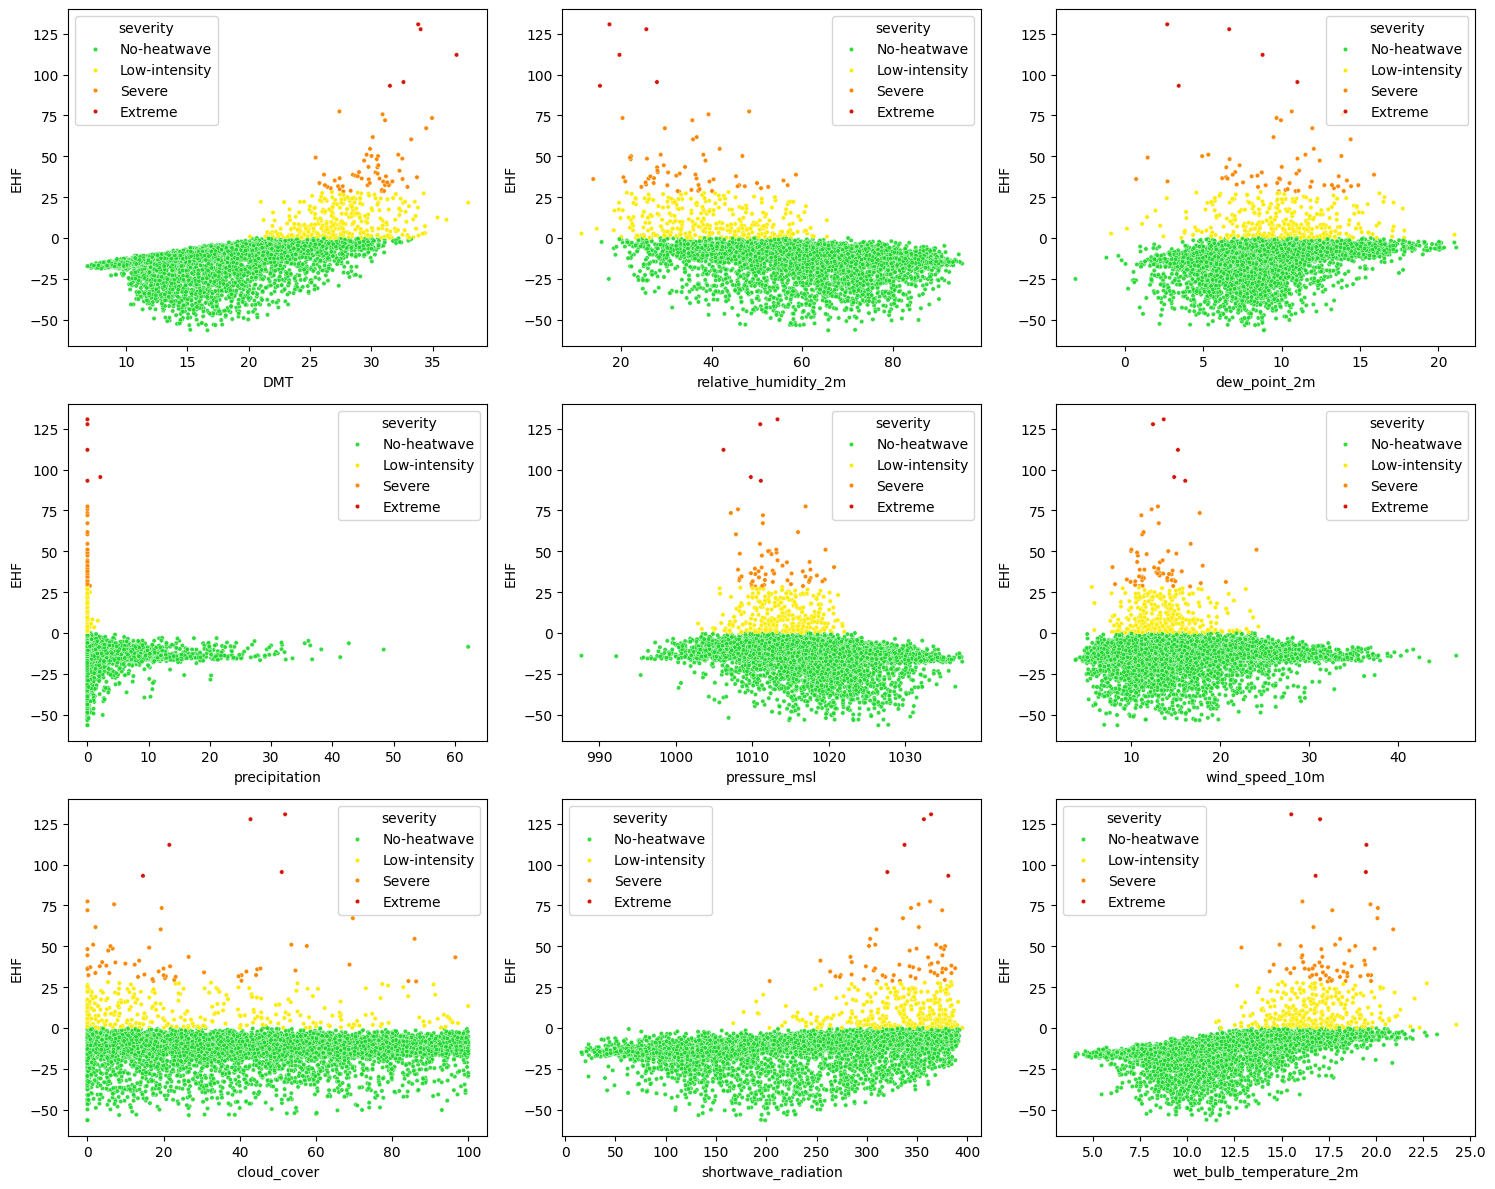

In [73]:
joint_plots_with_severity(daily_df, cols, 'EHF', 'severity', colors, type='scatter')

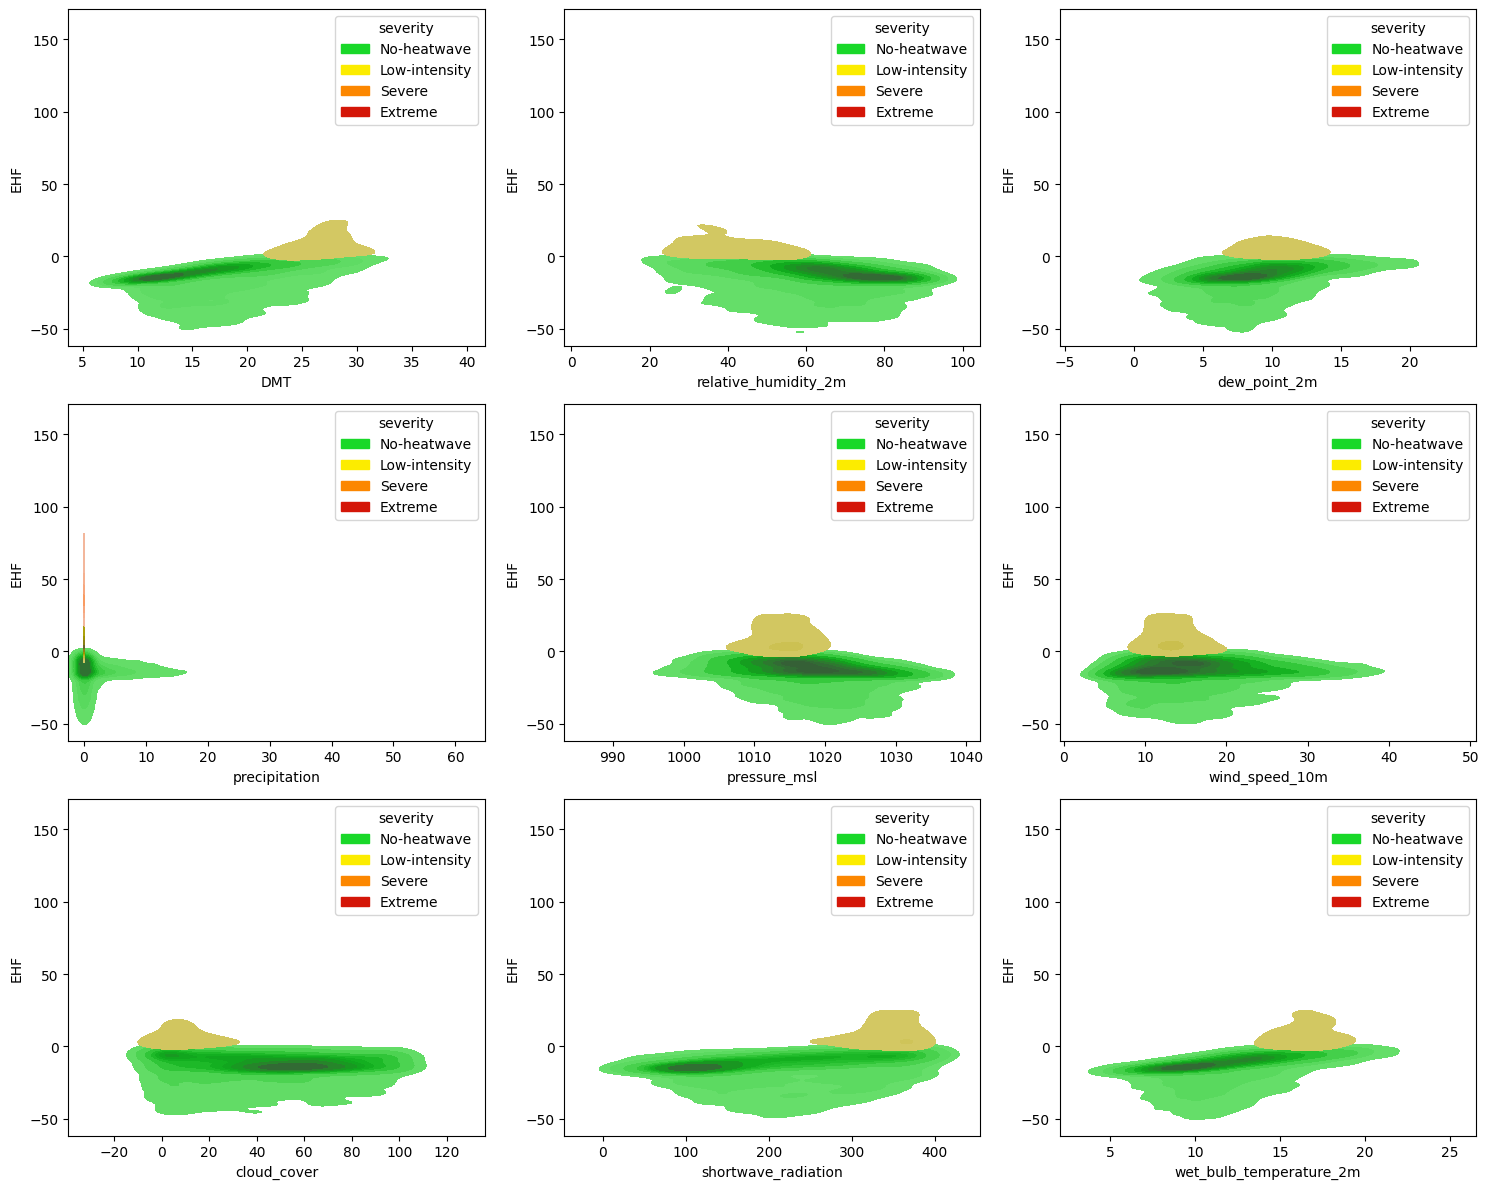

In [74]:
joint_plots_with_severity(daily_df, cols, 'EHF', 'severity', type='kde', palette=colors)

Here we can see in these scatter and density joint plots that, there is dense *'No-heatwave'* parts at intervals where heatwave instances covers. `precipitation`, `pressure_msl` and `wind_speed_10m` are best examples of this situation. 

These plots are generated to show *No-Heatwave* coverage in more clear way. Inferences and analysis of individual variables are same as we've done at section above ``'severity' Column Analysis``.

# Outro and Conclusion

Heatwave instances and different severity instances gathered in shallow intervals given an other feature, for most of the features. However since heatwaves are rare events, they are covered up with non-heatwave instances. Although, still as we've touched previously: With *derived features with feature engineering*, *multivariate dynamics* and *non-linear* models, there is still possibility to predict heatwaves in short term. And that is our main goal as project ongoing.

# Bottom